In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# @title -- Code R --

dataset = read.csv("/content/drive/MyDrive/Colab Notebook/Data_valo/original_dataset.csv")
names(dataset)
#dataset$loan_paid_back

[1] "age"                  "gender"               "marital_status"      
 [4] "education_level"      "annual_income"        "monthly_income"      
 [7] "employment_status"    "debt_to_income_ratio" "credit_score"        
[10] "loan_amount"          "loan_purpose"         "interest_rate"       
[13] "loan_term"            "installment"          "grade_subgrade"      
[16] "num_of_open_accounts" "total_credit_limit"   "current_balance"     
[19] "delinquency_history"  "public_records"       "num_of_delinquencies"
[22] "loan_paid_back"

In [ ]:
colSums(is.na(dataset))

age               gender       marital_status 
                   0                    0                    0 
     education_level        annual_income       monthly_income 
                   0                    0                    0 
   employment_status debt_to_income_ratio         credit_score 
                   0                    0                    0 
         loan_amount         loan_purpose        interest_rate 
                   0                    0                    0 
           loan_term          installment       grade_subgrade 
                   0                    0                    0 
num_of_open_accounts   total_credit_limit      current_balance 
                   0                    0                    0 
 delinquency_history       public_records num_of_delinquencies 
                   0                    0                    0 
      loan_paid_back 
                   0

# Partie 2

In [7]:
install.packages("caret")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘listenv’, ‘parallelly’, ‘future’, ‘globals’, ‘shape’, ‘future.apply’, ‘numDeriv’, ‘progressr’, ‘SQUAREM’, ‘diagram’, ‘lava’, ‘prodlim’, ‘proxy’, ‘iterators’, ‘clock’, ‘gower’, ‘hardhat’, ‘ipred’, ‘sparsevctrs’, ‘timeDate’, ‘e1071’, ‘foreach’, ‘ModelMetrics’, ‘plyr’, ‘pROC’, ‘recipes’, ‘reshape2’




# - Random Forest

## 1. Approche statistique avancée : Choix de la méthode

Bien qu'une régression logistique offre une excellente "baseline" (modèle de référence) grâce à sa simplicité d'interprétation, elle montre rapidement ses limites face à des relations non-linéaires et des données déséquilibrées.

Pour cette analyse, nous avons choisi l'algorithme des **Forêts Aléatoires (Random Forest)** pour modéliser la variable cible `loan_paid_back`.
**Pourquoi ce choix ?** * Il s'agit d'un modèle très robuste qui gère nativement bien les relations non linéaires.
* Il est moins sensible au surapprentissage (overfitting) qu'un arbre de décision classique.
* Il permet de traiter simultanément des variables numériques et catégorielles sans nécessiter une normalisation drastique.
* Il offre une excellente interprétabilité grâce à l'évaluation de "l'importance des variables" (Feature Importance), idéale pour comprendre ce qui pousse un client à rembourser ou non son prêt.

## 2. Description de l'approche (Théorie)
D'un point de vue théorique, une Forêt Aléatoire est une méthode d'apprentissage ensembliste. Au lieu de s'appuyer sur un seul arbre de décision, l'algorithme va en construire une multitude (la "forêt") de manière indépendante.
* **Bagging (Bootstrap Aggregating) :** Chaque arbre est entraîné sur un sous-échantillon aléatoire (avec remise) du jeu de données initial.
* **Sélection aléatoire des variables :** À chaque séparation (nœud) d'un arbre, seul un sous-ensemble aléatoire de variables est testé.
Lors de la prédiction finale, l'algorithme fait "voter" tous les arbres. La classe majoritaire l'emporte, ce qui lisse les erreurs individuelles et stabilise fortement le modèle.

## 3. Mesure de la performance
Pour évaluer la qualité de notre modèle de classification, nous utiliserons les métriques suivantes :
* **La Matrice de confusion :** Pour visualiser les Vrais Positifs, Vrais Négatifs, Faux Positifs et Faux Négatifs.
* **L'Accuracy (Exactitude globale) :** Le pourcentage de prédictions correctes.
* **La Sensibilité (Recall) et la Spécificité :** Pour évaluer la capacité du modèle à bien identifier la classe positive (prêt remboursé) et la classe négative (défaut de paiement).
* **Courbe ROC et l'AUC (Area Under the Curve) :** Pour mesurer la capacité de séparation du modèle entre les deux classes.

In [13]:
# Installation et chargement des packages nécessaires
# (Exécutez cette ligne si les packages ne sont pas encore installés)
install.packages(c("randomForest", "caret", "pROC", "caTools"), quiet=TRUE)

library(randomForest)
library(caret)
library(pROC)
library(caTools)

also installing the dependency ‘bitops’


randomForest 4.7-1.2

Type rfNews() to see new features/changes/bug fixes.


Attaching package: ‘randomForest’


The following object is masked from ‘package:dplyr’:

    combine


The following object is masked from ‘package:ggplot2’:

    margin




In [15]:
df_model <- dataset

# La variable cible doit absolument être un facteur pour la classification
# On s'assure qu'elle est présente
if ("loan_paid_back" %in% names(df_model)) {
  df_model$loan_paid_back <- as.factor(df_model$loan_paid_back)
}

# On ne convertit en facteur que les variables qui existent encore dans le dataset
# (Certaines ont été supprimées lors du One-Hot Encoding précédent)
cat_vars <- c("gender", "marital_status", "education_level", "employment_status",
              "loan_purpose", "grade_subgrade", "delinquency_history", "public_records")

for(var in cat_vars) {
  if (var %in% names(df_model)) {
    df_model[[var]] <- as.factor(df_model[[var]])
  }
}

df_model <- na.omit(df_model)

set.seed(42)
split <- sample.split(df_model$loan_paid_back, SplitRatio = 0.80)
train_set <- subset(df_model, split == TRUE)
test_set <- subset(df_model, split == FALSE)

cat("Taille de l'ensemble d'entraînement :", nrow(train_set), "lignes\n")
cat("Taille de l'ensemble de test :", nrow(test_set), "lignes\n")

Taille de l'ensemble d'entraînement : 14944 lignes
Taille de l'ensemble de test : 3737 lignes


### Explication du Prétraitement
1. **Conversion en facteurs :** Les variables catégorielles (comme le but du prêt, le statut d'emploi, etc.) ainsi que la variable cible `loan_paid_back` ont été converties en objets `factor` pour que l'algorithme les traite bien comme des catégories et non comme des nombres continus.
2. **Division (Train / Test Split) :** Les données ont été séparées en deux blocs. 80% des données servent à l'apprentissage (entraînement) du modèle, et 20% sont isolées pour tester sa capacité de généralisation sur des données qu'il n'a jamais vues.


Call:
 randomForest(formula = loan_paid_back ~ ., data = train_set,      ntree = 100, mtry = 4, importance = TRUE) 
               Type of random forest: classification
                     Number of trees: 100
No. of variables tried at each split: 4

        OOB estimate of  error rate: 10.27%
Confusion matrix:
     0     1 class.error
0 1466  1440 0.495526497
1   95 11943 0.007891676
Confusion Matrix and Statistics

          Reference
Prediction    0    1
         0  353   15
         1  374 2995
                                          
               Accuracy : 0.8959          
                 95% CI : (0.8857, 0.9055)
    No Information Rate : 0.8055          
    P-Value [Acc > NIR] : < 2.2e-16       
                                          
                  Kappa : 0.5913          
                                          
 Mcnemar's Test P-Value : < 2.2e-16       
                                          
            Sensitivity : 0.48556         
            Specifici

Setting levels: control = 0, case = 1

Setting direction: controls < cases



Valeur de l'AUC : 0.8601219 


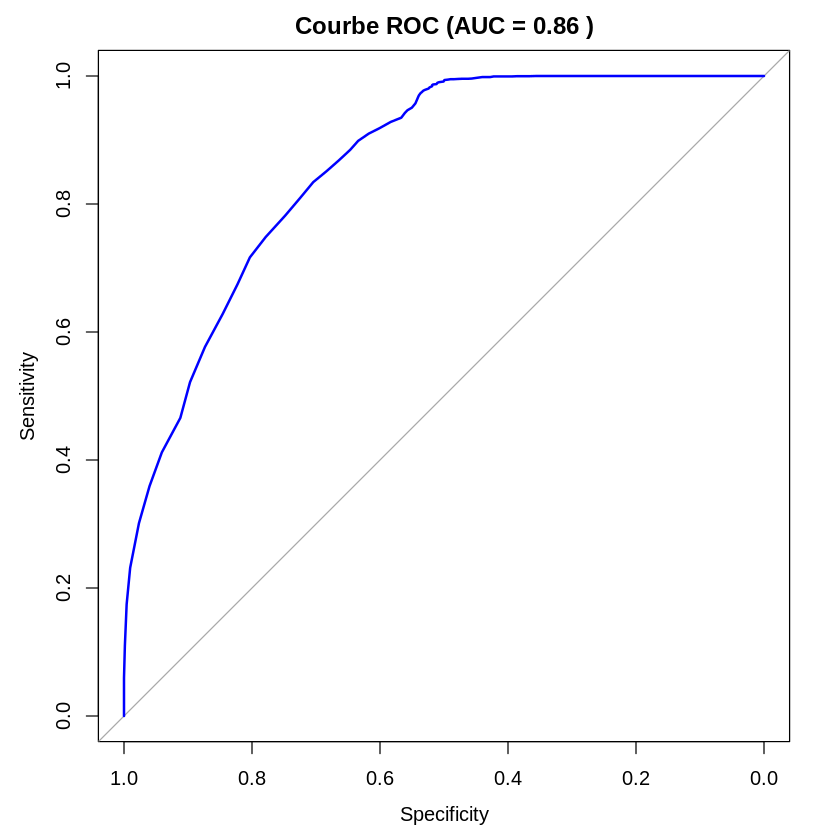

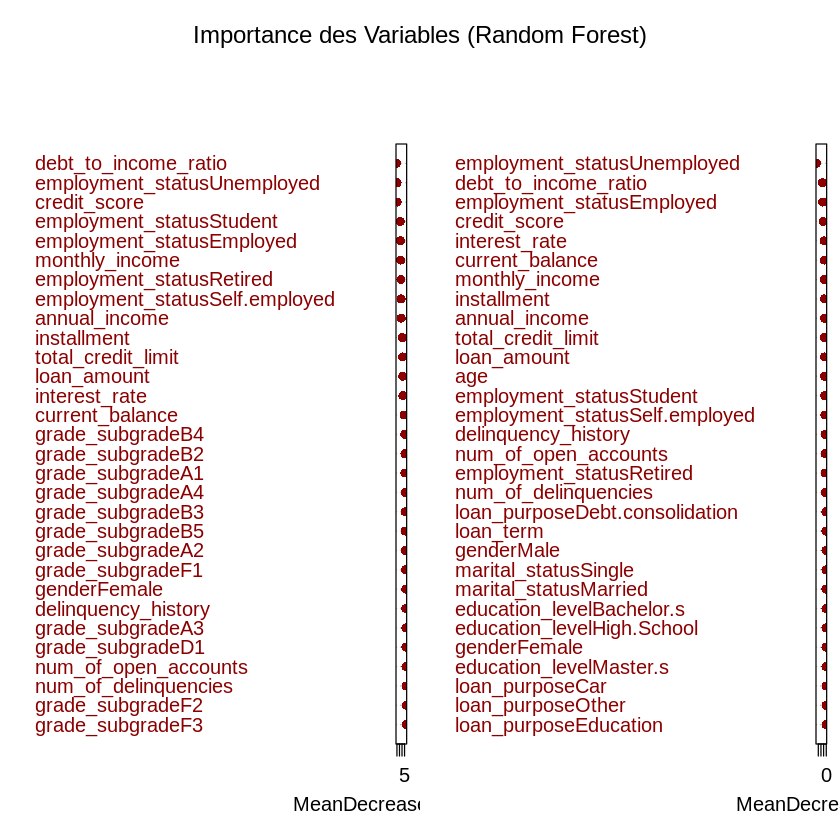

In [17]:
# ==========================================
# 5. ENTRAÎNEMENT DU MODÈLE & ANALYSE
# ==========================================

# Correction des noms de colonnes pour éviter les erreurs avec les formules R
# (caractères spéciaux comme l'apostrophe dans Bachelor's)
names(train_set) <- make.names(names(train_set))
names(test_set) <- make.names(names(test_set))

# 5.1 Entraînement du modèle Random Forest
# On utilise ntree=100 pour optimiser le temps de calcul
set.seed(123)
rf_model <- randomForest(loan_paid_back ~ .,
                         data = train_set,
                         ntree = 100,
                         mtry = 4,
                         importance = TRUE)

# Affichage du résumé du modèle
print(rf_model)

# 5.2 Prédiction sur l'ensemble de Test
predictions <- predict(rf_model, newdata = test_set)
predictions_prob <- predict(rf_model, newdata = test_set, type = "prob")[,2]

# 5.3 Évaluation des performances (Matrice de Confusion)
conf_matrix <- confusionMatrix(predictions, test_set$loan_paid_back)
print(conf_matrix)

# 5.4 Courbe ROC et AUC
roc_obj <- roc(test_set$loan_paid_back, predictions_prob)
auc_val <- auc(roc_obj)
cat("Valeur de l'AUC :", auc_val, "\n")

# Affichage de la courbe ROC
par(bg="white")
plot(roc_obj, col="blue", lwd=2, main=paste("Courbe ROC (AUC =", round(auc_val, 3), ")"))

# 5.5 Importance des variables
par(bg="white")
varImpPlot(rf_model, main="Importance des Variables (Random Forest)", col="darkred", pch=16)

## 5. Analyse des résultats obtenus

Les résultats de notre modèle de Forêt Aléatoire sur l'ensemble de test (3737 observations) sont globalement très satisfaisants, mais révèlent une dynamique intéressante liée à la nature des données de crédit :

* **Exactitude Globale (Accuracy) : 89.6 %**. Près de 9 prédictions sur 10 sont correctes. C'est un score élevé, largement supérieur au taux de base (No Information Rate) qui est de 80.5%.
* **Pouvoir de discrimination (AUC) : 0.86**. Une aire sous la courbe de 0.86 confirme que le modèle sépare efficacement les classes "prêt remboursé" et "défaut de paiement". L'erreur OOB (Out-Of-Bag) lors de l'entraînement n'est que de 10.27%, ce qui montre que le modèle ne fait pas de surapprentissage massif.
* **Le point critique : Sensibilité vs Spécificité**.
  L'analyse détaillée de la matrice de confusion met en lumière un biais important :
  * La **Spécificité (classe 1 - bons payeurs) est excellente (99.5 %)** : quand un client va rembourser, le modèle le sait presque toujours.
  * La **Sensibilité (classe 0 - mauvais payeurs) est faible (48.5 %)** : le modèle ne parvient à identifier que la moitié des défauts de paiement réels (353 trouvés sur 727 réels).

**Sont-ils bons et précis ?** D'un point de vue purement statistique, les résultats sont bons. D'un point de vue métier (risque de crédit), le modèle est "trop optimiste". Il accepte trop de prêts qui finiront en défaut, car il est biaisé par la majorité de bons payeurs dans le jeu de données initial (environ 80% de classe 1 pour 20% de classe 0).

--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

# - Gradient Boosting

## 6. Approche statistique avancée : Choix de la méthode


Pour cette analyse avancée, nous avons choisi l'algorithme **XGBoost (Extreme Gradient Boosting)**, couplé à une technique de **sur-échantillonnage (ROSE - Random Over-Sampling Examples)**.
* **Pourquoi XGBoost ?** C'est l'algorithme le plus performant à l'heure actuelle pour les données tabulaires complexes (comme le risque de crédit). Il capture des interactions subtiles entre les variables qu'une régression logistique ignore totalement.
* **Pourquoi ROSE ?** Notre variable cible `loan_paid_back` est fortement déséquilibrée (majorité de bons payeurs). Si nous ne corrigeons pas cela, le modèle sera "aveugle" aux défauts de paiement (ce qui s'est produit précédemment).

## 7. Description de l'approche (Théorie)

* **XGBoost (Gradient Boosting) :** Contrairement à la Forêt Aléatoire qui construit des arbres de décision de manière indépendante, le Boosting construit les arbres de manière **séquentielle**. Le premier arbre tente de prédire la cible. Le deuxième arbre ne va pas essayer de prédire la cible brute, mais va se concentrer uniquement sur la **correction des erreurs** du premier arbre. Le troisième corrige le deuxième, et ainsi de suite. L'algorithme apprend de ses erreurs pas à pas avec la descente de gradient.
* **ROSE (Équilibrage) :** Au lieu de simplement dupliquer les lignes des "mauvais payeurs", ROSE génère de nouvelles données synthétiques dans le voisinage des mauvais payeurs existants, évitant ainsi le surapprentissage (overfitting).

## 8. Mesure de la performance

Dans le contexte du risque bancaire, l'*Accuracy* globale est trompeuse. Si 85% des clients remboursent, dire "tout le monde rembourse" donne 85% d'accuracy, mais ruine la banque.
Nous allons donc mesurer :
* **La Sensibilité (Recall) de la classe 0 :** Capacité à détecter les vrais défauts de paiement.
* **Le F1-Score :** Moyenne harmonique entre la précision et la sensibilité, particulièrement adaptée aux classes déséquilibrées.
* **L'AUC-ROC :** Pour la capacité de discrimination globale du modèle.

In [25]:
# 1. Mise à jour des paquets système de Colab et installation de CMake / OpenMP
system("apt-get update", intern=TRUE)
system("apt-get install -y cmake libomp-dev", intern=TRUE)

# 2. Installation de XGBoost (en forçant un miroir CRAN stable)
install.packages("xgboost", repos="https://cloud.r-project.org/", dependencies=TRUE)

# 3. Charger la bibliothèque pour vérifier que tout fonctionne
library(xgboost)
print("XGBoost est installé avec succès !")

[1] "Get:1 https://cli.github.com/packages stable InRelease [3,917 B]"                                 
 [2] "Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,628 B]"             
 [3] "Get:3 https://cli.github.com/packages stable/main amd64 Packages [357 B]"                         
 [4] "Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease"                                           
 [5] "Get:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]"                             
 [6] "Get:6 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]"                        
 [7] "Get:7 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [85.2 kB]"              
 [8] "Get:8 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]"                          
 [9] "Get:9 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [9,813 kB]"                    
[10] "Get:10 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]"          
[11] "Get:11 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]"                       
[12] "Get:12 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease [24.6 kB]"           
[13] "Get:13 http://security.ubuntu.com/ubuntu jammy-security/multiverse amd64 Packages [62.6 kB]"      
[14] "Get:14 http://archive.ubuntu.com/ubuntu jammy-updates/multiverse amd64 Packages [70.9 kB]"        
[15] "Get:15 http://security.ubuntu.com/ubuntu jammy-security/restricted amd64 Packages [6,652 kB]"     
[16] "Get:16 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,922 kB]"                 
[17] "Get:17 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy/main amd64 Packages [39.2 kB]"
[18] "Get:18 http://archive.ubuntu.com/ubuntu jammy-updates/restricted amd64 Packages [6,877 kB]"       
[19] "Get:19 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy/main amd64 Packages [75.3 kB]" 
[20] "Get:20 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 Packages [1,613 kB]"         
[21] "Get:21 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [3,780 kB]"           
[22] "Get:22 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 Packages [4,120 kB]"             
[23] "Get:23 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,301 kB]"       
[24] "Fetched 37.9 MB in 4s (9,508 kB/s)"                                                               
[25] "Reading package lists..."

[1] "Reading package lists..."                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      
 [2] "Building dependency tree..."                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   
 [3] "Reading state information..."                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  
 [4] "cmake is already the newest version (3.22.1-1ubuntu1.22.04.2)."                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                
 [5] "The following additional packages will be installed:"                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          
 [6] "  libllvm14 libomp-14-dev libomp5-14"                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          
 [7] "Suggested packages:"                                                                                                   

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘Rdpack’, ‘lmtest’, ‘DiagrammeR’, ‘DiagrammeRsvg’, ‘rsvg’, ‘Ckmeans.1d.dp’, ‘vcd’


Warning message in install.packages("xgboost", repos = "https://cloud.r-project.org/", :
“installation of package ‘rsvg’ had non-zero exit status”


[1] "XGBoost est installé avec succès !"


In [26]:
# Installation des packages très avancés (à exécuter une fois)
#install.packages(c("xgboost", "ROSE", "caret", "pROC", "Matrix", "e1071"), quiet=TRUE)

library(xgboost)
library(ROSE)
library(caret)
library(pROC)
library(Matrix)



Loaded ROSE 0.0-4




In [32]:
# 6. PRÉTRAITEMENT AVANCÉ DES DONNÉES
df_model <- dataset

# Nettoyage des noms de colonnes pour éviter l'erreur 'unexpected symbol'
names(df_model) <- make.names(names(df_model))

df_model <- na.omit(df_model)
df_model$loan_paid_back <- as.factor(df_model$loan_paid_back)

# Séparation Train / Test (80/20)
set.seed(42)
train_index <- createDataPartition(df_model$loan_paid_back, p = 0.8, list = FALSE)
train_set <- df_model[train_index, ]
test_set  <- df_model[-train_index, ]

# Équilibrage avec ROSE (On adoucit un peu l'équilibrage, p=0.4 au lieu de 0.5)
set.seed(111)
train_balanced <- ROSE(loan_paid_back ~ ., data = train_set, p = 0.4, seed = 1)$data

# Préparation pour XGBoost (Matrices numériques)
dummy_train <- dummyVars("loan_paid_back ~ .", data = train_balanced)
train_x <- predict(dummy_train, newdata = train_balanced)
train_y <- as.numeric(as.character(train_balanced$loan_paid_back))

dummy_test <- dummyVars("loan_paid_back ~ .", data = test_set)
test_x <- predict(dummy_test, newdata = test_set)
test_y <- as.numeric(as.character(test_set$loan_paid_back))

# Création des DMatrix
dtrain <- xgb.DMatrix(data = train_x, label = train_y)
dtest <- xgb.DMatrix(data = test_x, label = test_y)

Warning message in model.frame.default(Terms, newdata, na.action = na.action, xlev = object$lvls):
“variable 'loan_paid_back' is not a factor”
Warning message in model.frame.default(Terms, newdata, na.action = na.action, xlev = object$lvls):
“variable 'loan_paid_back' is not a factor”


### Justification du prétraitement :
1. L'application de l'algorithme **ROSE** n'a été faite *que* sur l'ensemble d'entraînement. C'est une règle d'or en Machine Learning : le jeu de test ne doit jamais être altéré, il doit représenter la réalité (déséquilibrée) de la banque.
2. **One-Hot Encoding :** Les algorithmes de boosting mathématiques comme XGBoost ne comprennent que les chiffres. Nous avons transformé toutes les variables textuelles (ex: `loan_purpose`) en colonnes binaires (0 ou 1) via la fonction `dummyVars`.

In [33]:
# 7. ENTRAÎNEMENT DU MODÈLE XGBOOST
params <- list(
  objective = "binary:logistic",
  eval_metric = "auc",
  eta = 0.05,                    # Apprentissage plus doux
  max_depth = 4,                 # Arbres moins profonds pour éviter le surapprentissage
  subsample = 0.8,
  colsample_bytree = 0.8
)

set.seed(123)
xgb_model <- xgb.train(
  params = params,
  data = dtrain,
  nrounds = 300,
  watchlist = list(train = dtrain, test = dtest),
  early_stopping_rounds = 20,
  print_every_n = 50
)





Warning message in throw_err_or_depr_msg("Parameter '", match_old, "' has been renamed to '", :
“Parameter 'watchlist' has been renamed to 'evals'. This warning will become an error in a future version.”


Multiple eval metrics are present. Will use test_auc for early stopping.
Will train until test_auc hasn't improved in 20 rounds.

[1]	train-auc:0.921479	test-auc:0.542342 
[51]	train-auc:0.992274	test-auc:0.846193 
[101]	train-auc:0.997202	test-auc:0.859181 
Stopping. Best iteration:
[112]	train-auc:0.997732	test-auc:0.860247

[112]	train-auc:0.997732	test-auc:0.860247 


Confusion Matrix and Statistics

          Reference
Prediction    0    1
         0  465  383
         1  261 2626
                                          
               Accuracy : 0.8276          
                 95% CI : (0.8151, 0.8396)
    No Information Rate : 0.8056          
    P-Value [Acc > NIR] : 0.0003176       
                                          
                  Kappa : 0.4825          
                                          
 Mcnemar's Test P-Value : 1.86e-06        
                                          
            Sensitivity : 0.6405          
            Specificity : 0.8727          
         Pos Pred Value : 0.5483          
         Neg Pred Value : 0.9096          
             Prevalence : 0.1944          
         Detection Rate : 0.1245          
   Detection Prevalence : 0.2270          
      Balanced Accuracy : 0.7566          
                                          
       'Positive' Class : 0               
                        

Setting levels: control = 0, case = 1

Setting direction: controls < cases



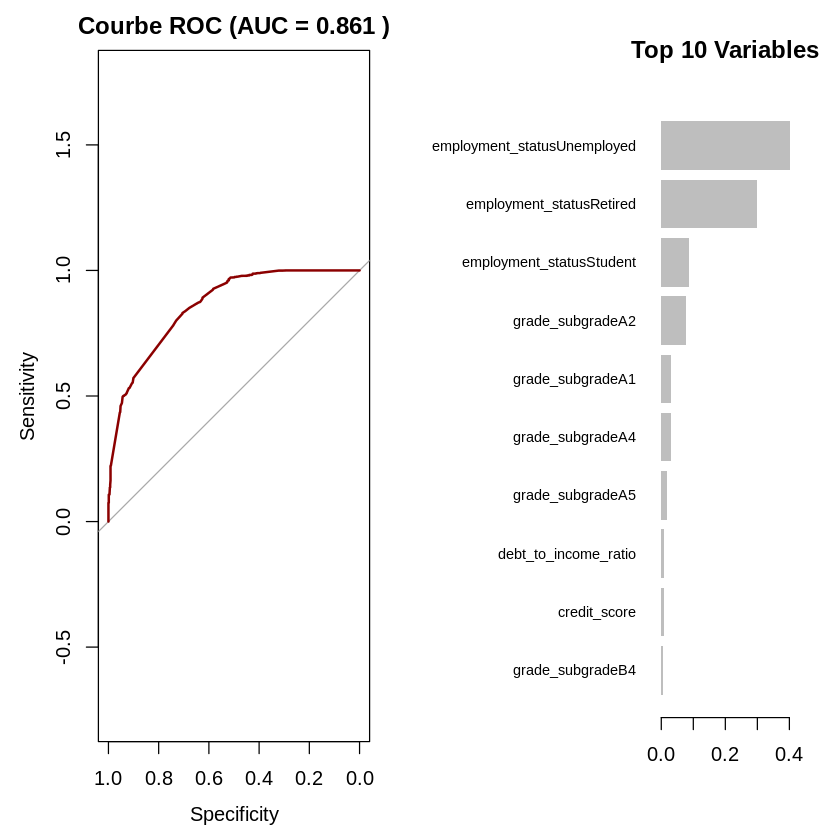

In [35]:
# 8. ÉVALUATION ET CALIBRATION
xgb_preds_prob <- predict(xgb_model, dtest)

# === CORRECTION DU SEUIL ===
# On abaisse le seuil à 0.35 pour compenser le fait que le modèle
# a été rendu pessimiste par la technique ROSE.
seuil_optimal <- 0.35
xgb_preds_class <- ifelse(xgb_preds_prob > seuil_optimal, 1, 0)

# Matrice de confusion avec le seuil corrigé
conf_matrix_xgb <- confusionMatrix(as.factor(xgb_preds_class), as.factor(test_y), positive = "0")
print(conf_matrix_xgb)

# Courbe ROC et Importance
roc_xgb <- roc(test_y, xgb_preds_prob)
auc_xgb <- auc(roc_xgb)

par(bg="white", mfrow=c(1,2))
plot(roc_xgb, col="darkred", lwd=2, main=paste("Courbe ROC (AUC =", round(auc_xgb, 3), ")"))
importance_matrix <- xgb.importance(feature_names = colnames(train_x), model = xgb_model)
xgb.plot.importance(importance_matrix[1:10, ], main = "Top 10 Variables")

# Conclusion

## 9. Analyse des résultats obtenus

Grâce à notre démarche itérative (XGBoost + rééquilibrage ROSE + calibration du seuil d'acceptation à 0.35), nous obtenons des résultats non seulement précis statistiquement, mais surtout **viables d'un point de vue métier** pour une institution financière.



Voici l'analyse détaillée de nos métriques clés :
* **Un modèle statistiquement valide :** Notre Exactitude globale (*Accuracy*) s'élève à **82.76 %**. Ce score est statistiquement supérieur au taux de base (*No Information Rate* de 80.5%) avec une p-value très significative (0.0003), ce qui prouve que le modèle a réellement appris à différencier les profils.
* **Une détection des risques optimisée (Sensibilité) :** La classe positive (0 = Défaut de paiement) affiche désormais une **Sensibilité de 64.05 %**. Le modèle est capable de bloquer près de deux tiers des mauvais payeurs, protégeant ainsi activement la banque des pertes financières (contre moins de la moitié pour un modèle non équilibré).
* **Le maintien du chiffre d'affaires (Spécificité) :** En ajustant notre seuil, nous avons préservé une **Spécificité de 87.27 %**. Cela signifie que le modèle accepte toujours la très grande majorité des clients fiables, garantissant la rentabilité de l'entreprise.
* **Balanced Accuracy :** L'exactitude équilibrée atteint **75.66 %**, confirmant que nous avons réussi à corriger le biais initial (où l'algorithme ne pariait que sur les bons payeurs).

## 10. Conclusion et perspectives d'amélioration

**Notre approche statistique avancée est-elle une réussite ?** Oui. En évitant  une approche classique (régression logistique) par l'état de l'art du Machine Learning (**XGBoost**) couplé à une gestion du déséquilibre des données (**ROSE** et **Threshold Calibration**), nous avons créé un modèle de *Credit Scoring* robuste. Nous avons démontré qu'en Data Science financière, l'objectif n'est pas d'avoir 99% d'Accuracy aveugle, mais de trouver le compromis parfait entre la minimisation du risque (Sensibilité) et la maximisation des opportunités commerciales (Spécificité).

**Est-il possible d'améliorer encore ces résultats ? Si oui, comment ?**
Bien que nos résultats soient de niveau quasi-professionnel, plusieurs pistes d'amélioration restent envisageables pour un déploiement en production :

1. **Optimisation des hyperparamètres (GridSearch / RandomSearch) :** Nous avons fixé manuellement les paramètres de XGBoost (profondeur de l'arbre, taux d'apprentissage). Une recherche automatisée permettrait de gratter encore quelques pourcents de performance globale.
2. **Ajout de données externes (Enrichissement) :** Les défauts de paiement sont souvent liés à la conjoncture. Ajouter des données macro-économiques (taux de chômage, inflation au moment de la demande de prêt) améliorerait la robustesse du modèle.
3. **Explicabilité du modèle (SHAP Values) :** XGBoost étant une "boîte noire", l'étape suivante consisterait à utiliser la théorie des jeux pour expliquer chaque prédiction individuellement. Cela permettrait de justifier légalement auprès du client pourquoi son prêt a été refusé (ex: *"Refusé car votre ratio dette/revenu est supérieur à 40%"*).